# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Tarea 02: Extracción y Transformación de Datos </center></h1>

**Fecha de Entrega:** 25 de septiembre de 2025, a las 23:59.

**Fecha de publicación**: 2 de septiembre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 02 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a través del canal de Tareas en el Foro del curso en Canvas.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

Para esta tarea, queremos comprender y visualizar la distribución de aves migratorias en el territorio chileno. Específicamente, queremos entender las diferencias entre las migraciones de 2 especies en particular, el run-run y la dormilona tontita, a partir de los avistamientos registrados en eBird durante un periodo de 3 años y medio.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

### 1.4 Ejemplo de visualización

Esta tarea se enfoca en datos de aves. Para complementarla, les compartimos la siguiente página web, llamada "Bird Migration Explorer" que les permite visualizar, de una forma novedosa e interesante, las rutas de migración de aves en las Americas. Visiten la página para que vean cómo se puede visualizar datos de una manera interesante y novedosa, que podría ustedes usar en el futuro para sus proyectos.

In [1]:
from IPython.display import IFrame
IFrame("https://explorer.audubon.org/home?layersPanel=expand", width=900, height=600)

## 2. Datos

Los datos a utilizar provienen de la plataforma **[eBird](https://ebird.org/)**, una aplicación desarrollada por The Cornell Lab of Ornithology que permite a sus usuarios registrar y compartir avistamientos de aves en todo el mundo. La plataforma dispone de una API mediante la cual se pueden realizar consultas sobre avistamientos de aves recientes e históricos, especies según región, taxonomía, entre otros. 

### 2.1 Acceso a la API

Muchas API pueden utilizarse solo mediante el uso de una clave única, o "API key". Para conseguir una API key en eBird, primero debe ser usuario de la plataforma. Puede crear una cuenta aquí: https://secure.birds.cornell.edu/identity/account/create


Con una cuenta ya creada, puede ingresar a https://ebird.org/api/keygen para generar su llave. Debe llenar un formulario de solicitud al pedir su llave. Como sugerencia, puede llenar los campos con la siguiente información:

* **Organización:** Pontificia Universidad Católica de Chile
* **Título del Proyecto:** Tarea IMT2200 Introducción a Ciencia de Datos
* **Descripción:** "Uso educativo para exploración y análisis de distribución de aves migratorias en Chile."
* **Tipo de Proyecto:** Academic/Student
* **Casos de uso:** Materiales educativos y artíticos (...)

Debería recibir su llave inmediatamente después de enviar su solicitud. Como recomendación, puede revisar la documentación de la API en el siguiente link: https://documenter.getpostman.com/view/664302/S1ENwy59#intro

#### 2.2 Mapoteca de BCN

Para esta tarea queremos visualizar el movimiento de aves a lo largo de nuestro país. Para ello, también necesitaremos manejar datos geoespaciales: específicamente, trabajaremos con un mapa vectorial de Chile disponible en la página web de la Biblioteca del Congreso Nacional: https://www.bcn.cl/siit/mapas_vectoriales/index_html

Descargue el archivo `.zip` para las **Divisiones regionales** y descomprímalo. Dentro de esta carpeta, habrá un archivo llamado `Regional.shp`, que utilizaremos con `geopandas` para graficar nuestro mapa de Chile.

### 2.3 Librerías

Para esta tarea recomendamos al menos usar las librerías indicadas en la siguiente celda del Notebook. Puede agregar otras si lo estima conveniente para responder de mejor forma las preguntas de la Tarea.

In [ ]:
import requests
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd



### ----------------------------------------
### Informacion necesaria:

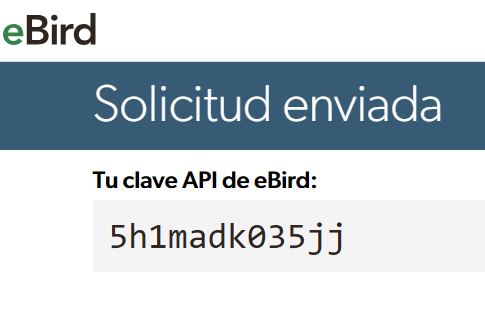

## 3. Desarrollo

Para cada una de las siguientes preguntas o actividades incluya una o más celdas de código y Markdown con las respuestas o comentarios necesarios para contestar la pregunta o lograr la actividad. Agregue sus celdas a continuación de cada pregunta para que el Notebook quede ordenado.

En el caso de gráficos, figuras o tablas, asegúrese que todas tengan título, etiquetas en los ejes o haya claridad de los contenidos.

### 3.1 Extracción de datos (1.5 puntos)

**(1 pto)** Vamos a crear nuestra base de datos con los avistamientos registrados en eBird dentro de Chile desde 2022 hasta 2025. Revise la documentación de la API y averigue cómo extraer los avistamientos de un día. Luego extraiga los avistamientos para todos los días desde el **1 de enero de 2022 hasta el 31 de julio de 2025.** Cuando haya logrado extraer todos los datos, guárdelos en un archivo CSV o parquet.

Responda:

**a) (0.2 pts)** ¿Cuántos avistamientos tiene su dataset?

**b) (0.3 pts)** Obtenga la cantidad de veces que se repite cada especie en su dataset y ordénelas de mayor a menor. ¿Qué pasa con la cantidad de avistamientos según especie? ¿Por qué?

**Recomendaciones:** 
* Puede usar la librería `datetime` para generar fechas: cree una lista con todas las fechas e itere sobre esta lista para hacer los llamados a la API.
* **Pruebe primero con uno o dos días** para verificar el funcionamiento de su código y de la API.
* Inspeccione la forma en la que vienen los datos.
* Vaya guardando los datos extraídos en archivos (CSV o parquet), de modo que no tenga que repetir los llamados en caso de algún error.

**Hint**: Los códigos regionales chilenos para la API son los siguientes,
* `regionCode = CL`
* `sppLocale = es_CL` (para obtener nombres chilenos de las aves)

### ----------------------------------------------------------------------------------------

### Markdown de testing, no lo mires es solo para guardar cosas
    print(dia_actual)
    dia_actual += salto_dia
    print(dia_actual)

    2022-01-02
    2022-01-03


    print(dia_actual,contador)

    2022-01-01 0
    2025-07-31 1307


    print(observacion.keys())
    print(observacion["obsDt"])

    dict_keys(['speciesCode', 'comName', 'sciName', 'locId', 'locName', 'obsDt', 'howMany', 'lat', 'lng', 'obsValid', 'obsReviewed', 'locationPrivate', 'subId'])
    2022-01-01 23:41

    ''' Codigo base
    fecha_inicio = datetime.date(2022,1, 1) # va en el formato year, moth, day
    fecha_final = datetime.date(2025,7,31)
    dia_actual = fecha_inicio
    salto_dia = datetime.timedelta(days=1)

    all_datatita = []

    while dia_actual <= fecha_final :    
        url = f"https://api.ebird.org/v2/data/obs/{REGION}/historic/{dia_actual.year}/{dia_actual.month}/{dia_actual.day}"
        response = requests.get(url, headers=headers)
        
        print(f"Dia actual: {dia_actual}\n")
        
        if response.status_code == 200 : #OK
            data = response.json()
            
            for observacion in data:
                #print(observacion.keys())
                #print(observacion["obsDt"])            
                all_datatita.append(observacion)
                
        else : #Tiro algun error probablemente, error de server u otra wea
            print(f"Error {response.status_code} en fecha: {dia_actual}")

        dia_actual += salto_dia
        
        
        break
        pass
    '''

In [4]:
%pwd

'c:\\GIT HUB DESKO\\IMT2200-Lucas-Chicao\\Tareas\\Tarea 2'

In [216]:
%cd ..

c:\GIT HUB DESKO\IMT2200-Lucas-Chicao\Tareas\Tarea 2


In [ ]:
# Respuesta 3.1 Extracion de datos xd
import requests
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

# Voy a utilizar datetime, asi hago un while y que vaya revisando dia por dia :3
# Voy a hacer una funcion que tome cada año y nomas luego nomas hago concat xd, es por si se cae en medio de la wea, dejare el codigo base comentado por si acaso nomas



def INFOMARCION_DO_PAJARINO(fecha_inicio: datetime.date, fecha_final: datetime.date) -> pd.DataFrame:
    
    API_KEY = "5h1madk035jj"
    REGION = "CL"
    headers = {"X-eBirdApiToken": API_KEY}
    pararametros = {
        "sppLocale": "es_CL"
                  }
    
    dia_actual = fecha_inicio
    salto_dia = datetime.timedelta(days=1)
    all_datatita = []
    
    while dia_actual <= fecha_final :    
        url = f"https://api.ebird.org/v2/data/obs/{REGION}/historic/{dia_actual.year}/{dia_actual.month}/{dia_actual.day}"
        response = requests.get(url, headers=headers, params=pararametros)
        
        print(f"Dia actual: {dia_actual}")
        
        if response.status_code == 200 : #OK
            data = response.json()
            
            for observacion in data:            
                all_datatita.append(observacion)
                
        else : #Tiro algun error probablemente, error de server u otra wea
            print(f"Error {response.status_code} en fecha: {dia_actual}")

        dia_actual += salto_dia
        
    
            
    return pd.DataFrame(all_datatita)
    

In [59]:
test_dataframio_2022 = INFOMARCION_DO_PAJARINO(datetime.date(2022,1,1), datetime.date(2022,1,31))
test_dataframio_2022.to_csv("ebird_2022.csv", index=False)


Dia actual: 2022-01-01
Dia actual: 2022-01-02
Dia actual: 2022-01-03
Dia actual: 2022-01-04
Dia actual: 2022-01-05
Dia actual: 2022-01-06
Dia actual: 2022-01-07
Dia actual: 2022-01-08
Dia actual: 2022-01-09
Dia actual: 2022-01-10
Dia actual: 2022-01-11
Dia actual: 2022-01-12
Dia actual: 2022-01-13
Dia actual: 2022-01-14
Dia actual: 2022-01-15
Dia actual: 2022-01-16
Dia actual: 2022-01-17
Dia actual: 2022-01-18
Dia actual: 2022-01-19
Dia actual: 2022-01-20
Dia actual: 2022-01-21
Dia actual: 2022-01-22
Dia actual: 2022-01-23
Dia actual: 2022-01-24
Dia actual: 2022-01-25
Dia actual: 2022-01-26
Dia actual: 2022-01-27
Dia actual: 2022-01-28
Dia actual: 2022-01-29
Dia actual: 2022-01-30
Dia actual: 2022-01-31


In [213]:
dataframio_2022 = INFOMARCION_DO_PAJARINO(datetime.date(2022,1,1), datetime.date(2022,12,31))
dataframio_2022.to_csv("ebird_2022.csv", index=False)

Dia actual: 2022-01-01
Dia actual: 2022-01-02
Dia actual: 2022-01-03
Dia actual: 2022-01-04
Dia actual: 2022-01-05
Dia actual: 2022-01-06
Dia actual: 2022-01-07
Dia actual: 2022-01-08
Dia actual: 2022-01-09
Dia actual: 2022-01-10
Dia actual: 2022-01-11
Dia actual: 2022-01-12
Dia actual: 2022-01-13
Dia actual: 2022-01-14
Dia actual: 2022-01-15
Dia actual: 2022-01-16
Dia actual: 2022-01-17
Dia actual: 2022-01-18
Dia actual: 2022-01-19
Dia actual: 2022-01-20
Dia actual: 2022-01-21
Dia actual: 2022-01-22
Dia actual: 2022-01-23
Dia actual: 2022-01-24
Dia actual: 2022-01-25
Dia actual: 2022-01-26
Dia actual: 2022-01-27
Dia actual: 2022-01-28
Dia actual: 2022-01-29
Dia actual: 2022-01-30
Dia actual: 2022-01-31
Dia actual: 2022-02-01
Dia actual: 2022-02-02
Dia actual: 2022-02-03
Dia actual: 2022-02-04
Dia actual: 2022-02-05
Dia actual: 2022-02-06
Dia actual: 2022-02-07
Dia actual: 2022-02-08
Dia actual: 2022-02-09
Dia actual: 2022-02-10
Dia actual: 2022-02-11
Dia actual: 2022-02-12
Dia actual:

In [217]:
dataframio_2023 = INFOMARCION_DO_PAJARINO(datetime.date(2023,1,1), datetime.date(2023,12,31))
dataframio_2023.to_csv("ebird_2023.csv", index=False)

Dia actual: 2023-01-01
Dia actual: 2023-01-02
Dia actual: 2023-01-03
Dia actual: 2023-01-04
Dia actual: 2023-01-05
Dia actual: 2023-01-06
Dia actual: 2023-01-07
Dia actual: 2023-01-08
Dia actual: 2023-01-09
Dia actual: 2023-01-10
Dia actual: 2023-01-11
Dia actual: 2023-01-12
Dia actual: 2023-01-13
Dia actual: 2023-01-14
Dia actual: 2023-01-15
Dia actual: 2023-01-16
Dia actual: 2023-01-17
Dia actual: 2023-01-18
Dia actual: 2023-01-19
Dia actual: 2023-01-20
Dia actual: 2023-01-21
Dia actual: 2023-01-22
Dia actual: 2023-01-23
Dia actual: 2023-01-24
Dia actual: 2023-01-25
Dia actual: 2023-01-26
Dia actual: 2023-01-27
Dia actual: 2023-01-28
Dia actual: 2023-01-29
Dia actual: 2023-01-30
Dia actual: 2023-01-31
Dia actual: 2023-02-01
Dia actual: 2023-02-02
Dia actual: 2023-02-03
Dia actual: 2023-02-04
Dia actual: 2023-02-05
Dia actual: 2023-02-06
Dia actual: 2023-02-07
Dia actual: 2023-02-08
Dia actual: 2023-02-09
Dia actual: 2023-02-10
Dia actual: 2023-02-11
Dia actual: 2023-02-12
Dia actual:

In [218]:
dataframio_2024 = INFOMARCION_DO_PAJARINO(datetime.date(2024,1,1), datetime.date(2024,12,31))
dataframio_2024.to_csv("ebird_2024.csv", index=False)

Dia actual: 2024-01-01
Dia actual: 2024-01-02
Dia actual: 2024-01-03
Dia actual: 2024-01-04
Dia actual: 2024-01-05
Dia actual: 2024-01-06
Dia actual: 2024-01-07
Dia actual: 2024-01-08
Dia actual: 2024-01-09
Dia actual: 2024-01-10
Dia actual: 2024-01-11
Dia actual: 2024-01-12
Dia actual: 2024-01-13
Dia actual: 2024-01-14
Dia actual: 2024-01-15
Dia actual: 2024-01-16
Dia actual: 2024-01-17
Dia actual: 2024-01-18
Dia actual: 2024-01-19
Dia actual: 2024-01-20
Dia actual: 2024-01-21
Dia actual: 2024-01-22
Dia actual: 2024-01-23
Dia actual: 2024-01-24
Dia actual: 2024-01-25
Dia actual: 2024-01-26
Dia actual: 2024-01-27
Dia actual: 2024-01-28
Dia actual: 2024-01-29
Dia actual: 2024-01-30
Dia actual: 2024-01-31
Dia actual: 2024-02-01
Dia actual: 2024-02-02
Dia actual: 2024-02-03
Dia actual: 2024-02-04
Dia actual: 2024-02-05
Dia actual: 2024-02-06
Dia actual: 2024-02-07
Dia actual: 2024-02-08
Dia actual: 2024-02-09
Dia actual: 2024-02-10
Dia actual: 2024-02-11
Dia actual: 2024-02-12
Dia actual:

In [219]:
#hasta el 2025 7 31
dataframio_2025 = INFOMARCION_DO_PAJARINO(datetime.date(2025,1,1), datetime.date(2025,7,31))
dataframio_2025.to_csv("ebird_2025.csv", index=False)




Dia actual: 2025-01-01
Dia actual: 2025-01-02
Dia actual: 2025-01-03
Dia actual: 2025-01-04
Dia actual: 2025-01-05
Dia actual: 2025-01-06
Dia actual: 2025-01-07
Dia actual: 2025-01-08
Dia actual: 2025-01-09
Dia actual: 2025-01-10
Dia actual: 2025-01-11
Dia actual: 2025-01-12
Dia actual: 2025-01-13
Dia actual: 2025-01-14
Dia actual: 2025-01-15
Dia actual: 2025-01-16
Dia actual: 2025-01-17
Dia actual: 2025-01-18
Dia actual: 2025-01-19
Dia actual: 2025-01-20
Dia actual: 2025-01-21
Dia actual: 2025-01-22
Dia actual: 2025-01-23
Dia actual: 2025-01-24
Dia actual: 2025-01-25
Dia actual: 2025-01-26
Dia actual: 2025-01-27
Dia actual: 2025-01-28
Dia actual: 2025-01-29
Dia actual: 2025-01-30
Dia actual: 2025-01-31
Dia actual: 2025-02-01
Dia actual: 2025-02-02
Dia actual: 2025-02-03
Dia actual: 2025-02-04
Dia actual: 2025-02-05
Dia actual: 2025-02-06
Dia actual: 2025-02-07
Dia actual: 2025-02-08
Dia actual: 2025-02-09
Dia actual: 2025-02-10
Dia actual: 2025-02-11
Dia actual: 2025-02-12
Dia actual:

In [220]:
lista_dataframios = [dataframio_2022,dataframio_2023,dataframio_2024,dataframio_2025]

n = 0
for i in lista_dataframios:
    n += len(i)
    print(len(i), n)
    

df_completo = pd.concat(lista_dataframios, ignore_index=True)
df_completo.to_csv("ebird_2022_2025.csv", index=False)

72370 72370
75770 148140
78610 226750
45445 272195


### ----------------------------------------------------------------------------------------

### En caso de que ya este subido el archivo csv y asi no tengas que cargar toda la cosa te dejo ese codigo que abre el csv y genera el dataframe apartir de ello

En teoria deberia tener 272195 tuplas sin considerar el encabezado 

In [1]:
import pandas as pd
archivo =  "ebird_2022_2025.csv"
df_completo = pd.read_csv(archivo)

In [3]:
len(df_completo)

272195

### ----------------------------------------------------------------------------------------

**a) (0.2 pts)** ¿Cuántos avistamientos tiene su dataset?


El dataset tiene 272195 avistamientos

In [5]:
# Respuesta a
'''
Tengo que hacer un print(len(dataframio_xxxx)) esto printeara la cantidad de filas que tiene sin considerar la primera fila, la cual sera para las columnas

print(len(test_dataframio_2022))-> int
'''
print(len(df_completo))


272195


**b) (0.3 pts)** Obtenga la cantidad de veces que se repite cada especie en su dataset y ordénelas de mayor a menor. ¿Qué pasa con la cantidad de avistamientos según especie? ¿Por qué?

-El conteo de avistamienots de cada especie esta en el archivo 'conteo_especies.csv' presente en el repositorio

-El .value_count() ya lo ordena de forma automatica de mayor a menor

-Es normal que algunas especies aparezcan mas que otras, esto se puede deber a varios factores, cambios climaticos, ubicacion de observadores, como tambien depende de la epoca en las que se observan 


In [ ]:
# Respuesta b
'''
Tengo que hacer un .value_count() a cada uno y luego sumarlo, no es necesario que añada un index, solo serie1 + serie2 
'''
avistamientos =  df_completo["comName"].value_counts()
avistamientos.to_csv("conteo_especies.csv", header=True)

### ----------------------------------------------------------------------------------------

### 3.2 Tranformación (1 punto)

**a) (0.5 pts)** Transforme la columna `obsDt` de string a un objeto de tipo `datetime` únicamente con año, mes y día (YYYY-MM-DD). Luego, agregue las siguientes nuevas columnas:
* `month` con únicamente el mes del avistamiento (puede dejar el mes como número entero de 1 a 12).
* `year-month` con el mes y año fecha en formato YYYY-MM

In [ ]:
# Respuesta
#type(test_dataframio_2022["obsDt"][0]) -> str

testing = test_dataframio_2022.copy()
# print(testing["obsDt"])  2022-01-01 23:41 


testing["obsDt"] = testing["obsDt"].str[:10] #esta wea nomas toma los primeros 10 elementos del str, los que representan justamente la fecha

#print(testing["obsDt"][0])
#print(testing["obsDt"][0][5:7])

testing["month"] = testing["obsDt"].str[5:7]
testing["year-month"] = testing["obsDt"].str[0:7]




0       2022-01
1       2022-01
2       2022-01
3       2022-01
4       2022-01
         ...   
6193    2022-01
6194    2022-01
6195    2022-01
6196    2022-01
6197    2022-01
Name: year-month, Length: 6198, dtype: object

**b) (0.5 pts)** Averigue cómo tranformar su DataFrame de Pandas en un GeoDataFrame de GeoPandas. Para esto, utilice las columnas `lat`y `lng` para generar los puntos de la nueva columna `geometry`. Para las visualizaciones siguientes utilizaremos el Coordinate Reference System (CRS) EPSG 4326 (también llamado [WGS 84](https://es.wikipedia.org/wiki/WGS84)). Asegúrese que sus coordenadas correspondan a este CRS al crear su GeoDataFrame.

In [ ]:
'''
lat es de latitud
lng es de longitud
print(testing['lat'])-> Cordenadas 
print(testing['lng'])-> Cordenadas

geo_df_testing["geometry"]
>0       POINT (-73.11316 -40.58584)
>1       POINT (-70.94766 -53.21457)
>2       POINT (-70.94766 -53.21457)
>3       POINT (-70.94766 -53.21457)
>4       POINT (-70.94766 -53.21457)
>...


por mientras voy a usar la tabla testing
'''
import geopandas as gpd


# Respuesta


geo_df_testing = gpd.GeoDataFrame(
                                data=testing, #el data es el dataframe que se toma (' _ConvertibleToDataFrame  ')
                                geometry= gpd.points_from_xy(testing["lng"], testing["lat"]),
                                crs="4326" #en la clase 4 (pdf) aparece algo de esto
                                )

#testing['lat']
#testing['lng']

geo_df_testing["geometry"]


0       POINT (-73.11316 -40.58584)
1       POINT (-70.94766 -53.21457)
2       POINT (-70.94766 -53.21457)
3       POINT (-70.94766 -53.21457)
4       POINT (-70.94766 -53.21457)
                   ...             
6193    POINT (-70.94766 -53.21457)
6194    POINT (-74.49972 -51.65694)
6195    POINT (-71.62161 -39.89038)
6196    POINT (-71.62161 -39.89038)
6197     POINT (-71.4792 -36.91051)
Name: geometry, Length: 6198, dtype: geometry

### 3.3 Exploración del dataset (1 punto)

**a) (0.3 pts)** Utilice `geopandas` para leer el archivo `Regional.shp` descargado de BCN. Asegúrese de que su CRS sea el mismo que utilizó en la sección anterior.

In [132]:
%pwd

'c:\\GIT HUB DESKO\\IMT2200-Lucas-Chicao\\Tareas\\Tarea 2\\data_general'

In [140]:
%cd ..

c:\GIT HUB DESKO\IMT2200-Lucas-Chicao\Tareas\Tarea 2


In [142]:
%ls 

 Volume in drive C has no label.
 Volume Serial Number is 9E56-4120

 Directory of c:\GIT HUB DESKO\IMT2200-Lucas-Chicao\Tareas\Tarea 2\data_general\Regiones

09/20/2025  02:48 PM    <DIR>          .
09/20/2025  02:49 PM    <DIR>          ..
09/20/2025  02:48 PM                 5 Regional.CPG
09/20/2025  02:48 PM             2,604 Regional.dbf
09/20/2025  02:48 PM               425 Regional.prj
09/20/2025  02:48 PM               276 Regional.sbn
09/20/2025  02:48 PM               124 Regional.sbx
09/20/2025  02:48 PM        53,751,340 Regional.shp
09/20/2025  02:48 PM            24,091 Regional.shp.xml
09/20/2025  02:48 PM               236 Regional.shx
               8 File(s)     53,779,101 bytes
               2 Dir(s)  27,137,949,696 bytes free


In [141]:
%cd data_general/Regiones

c:\GIT HUB DESKO\IMT2200-Lucas-Chicao\Tareas\Tarea 2\data_general\Regiones


In [1]:
# Respuesta
regional = gpd.read_file("Regional.shp")
print(regional.crs)

NameError: name 'gpd' is not defined

Como vemos que no tienen el mismo crs se lo cambiamos

In [149]:
regional = regional.to_crs(epsg=4326) #por alguna extraña razon no se cambia el objeto en si si no que se crea otro xd
print(regional.crs)

EPSG:4326


In [150]:
print(regional.crs)

EPSG:4326


**b) (0.7 pts)** Grafique un mapa de Chile con todos los avistamientos de su dataset como puntos en el mapa. Comente: ¿Cómo se distribuyen estos avistamientos? ¿Hay lugares en Chile donde haya una menor densidad de datos? ¿Cuáles? 

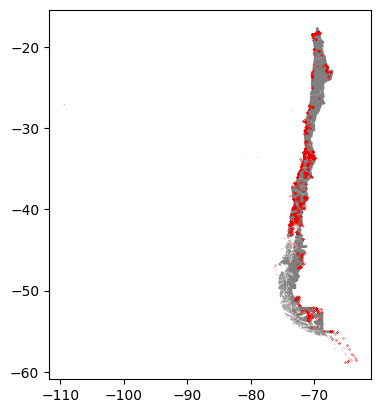

In [206]:
# Respuesta
import matplotlib.pyplot as plt
#Uso lo subplots para luego poder unir las leseras
# print(plt.subplots()) -> (<Figure size 640x480 with 1 Axes>, <Axes: >)

# print(type(plt.subplots())) -> tuple
# print(type(plt.subplots()[0])) -> matplotlib.figure.Figure
# print(type(plt.subplots()[1])) -> <class 'matplotlib.axes._axes.Axes'>

wea = plt.subplots()
axes = wea[1]

regional.plot(ax=axes, color="grey")
geo_df_testing.plot(ax=axes,color="red", markersize=0.01)
plt.show()


### 3.4 Visualización de migraciones (2.5 puntos)

**a) (0.2 pts)** Vamos a inspeccionar los avistamientos de las siguientes 2 especies en particular:

* Run-run [(*Hymenops perspicillatus*)](https://www.avesdechile.cl/171.htm)
* Dormilona tontita [(*Muscisaxicola maclovianus*)](https://www.avesdechile.cl/043.htm)

Primero, genere dos nuevos dataframes con los avistamientos de cada especie por separado.

In [ ]:
# Respuesta

**b) (0.8 pts)** Para cada una de estas especies, agrupe los datos según `year-month`. Luego, realice un gráfico que muestre la cantidad de avistamientos en el tiempo, empezando desde enero del 2022 hasta julio de 2025. Responda: ¿cómo varía cantidad de avistamientos para estas dos especies? ¿Cuáles son sus diferencias?

In [ ]:
# Respuesta

**b) (1 pto)** Grafique en un mapa de Chile la ubicación de cada avistamiento para cada especie mencionada por separado. Utilice el color de cada punto como indicador del mes de avistamiento (columna `month`). Para esto, utilice un **colormap cíclico** para representar los meses del año. Puede utilizar el colormap disponible en la siguiente celda, o bien utilizar otro (siempre y cuando sea cíclico).

In [ ]:
import matplotlib.colors as mcolors
colors = ["coral", "blue", "coral"]
positions = [0, 0.5, 1]

# Creamos un colormap cíclico para representar meses del año
custom_cmap = mcolors.LinearSegmentedColormap.from_list("cyclic_cmap", list(zip(positions, colors)))

In [ ]:
# Respuesta

**c) (0.5 pts)** Describa las migraciones de estas dos especies. ¿Cómo se diferencian?

Respuesta